In [19]:
import os
import copy
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [20]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 15
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [21]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        self.enc1 = self._double_conv(in_channels, 64)
        self.enc2 = self._double_conv(64, 128)
        self.enc3 = self._double_conv(128, 256)
        self.enc4 = self._double_conv(256, 512)

        self.bottleneck = self._double_conv(512, 1024)

        self.upconv4 = self._up_conv(1024, 512)
        self.dec4 = self._double_conv(1024, 512)

        self.upconv3 = self._up_conv(512, 256)
        self.dec3 = self._double_conv(512, 256)

        self.upconv2 = self._up_conv(256, 128)
        self.dec2 = self._double_conv(256, 128)

        self.upconv1 = self._up_conv(128, 64)
        self.dec1 = self._double_conv(128, 64)

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

        self.pool = nn.MaxPool2d(2)

    def _double_conv(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def _up_conv(self, in_channels, out_channels):
        return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x):
        enc1 = self.enc1(x)
        enc1_pooled = self.pool(enc1)

        enc2 = self.enc2(enc1_pooled)
        enc2_pooled = self.pool(enc2)

        enc3 = self.enc3(enc2_pooled)
        enc3_pooled = self.pool(enc3)

        enc4 = self.enc4(enc3_pooled)
        enc4_pooled = self.pool(enc4)

        bottleneck = self.bottleneck(enc4_pooled)

        up4 = self.upconv4(bottleneck)
        up4 = torch.cat([up4, enc4], dim=1)
        dec4 = self.dec4(up4)

        up3 = self.upconv3(dec4)
        up3 = torch.cat([up3, enc3], dim=1)
        dec3 = self.dec3(up3)

        up2 = self.upconv2(dec3)
        up2 = torch.cat([up2, enc2], dim=1)
        dec2 = self.dec2(up2)

        up1 = self.upconv1(dec2)
        up1 = torch.cat([up1, enc1], dim=1)
        dec1 = self.dec1(up1)

        output = self.final_conv(dec1)

        return output

In [22]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [23]:
class Trainer:
    def __init__(self, config, model=None):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        self.model = model if model is not None else UNet().to(config.device)
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.train_losses = []
        self.val_losses = []
        self.val_ious = []
        self.val_f1s = []

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self, verbose=True):
        self.train_losses = []
        self.val_losses = []
        self.val_ious = []
        self.val_f1s = []

        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.val_ious.append(val_iou)
            self.val_f1s.append(val_f1)

            if verbose:
                print(f"Epoch {epoch+1} / {self.config.epochs}, "
                      f"Train Loss: {train_loss:.4f}, "
                      f"Val Loss: {val_loss:.4f}, "
                      f"Val IoU: {val_iou:.4f}, "
                      f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()
        if verbose:
            print(f"Test Loss: {test_loss:.4f}, "
                  f"Test IoU: {test_iou:.4f}, "
                  f"Test F1-score: {test_f1:.4f}")

        return test_loss, test_iou, test_f1

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader, desc="Training", leave=False):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader, desc="Validation", leave=False):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader, desc="Testing"):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.tight_layout()
            plt.show()

    def plot_training_history(self):
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        axes[0].plot(self.train_losses, label='Train Loss', marker='o')
        axes[0].plot(self.val_losses, label='Val Loss', marker='s')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training and Validation Loss')
        axes[0].legend()
        axes[0].grid(True)

        axes[1].plot(self.val_ious, label='Val IoU', marker='o', color='green')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('IoU Score')
        axes[1].set_title('Validation IoU')
        axes[1].legend()
        axes[1].grid(True)

        axes[2].plot(self.val_f1s, label='Val F1', marker='s', color='orange')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('F1 Score')
        axes[2].set_title('Validation F1 Score')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()

    def tune_hyperparameters(self, lr_values=[1e-4, 1e-3], batch_sizes=[16, 32], epochs=5):
        results = []

        for lr in lr_values:
            for bs in batch_sizes:
                print(f"\nTraining with LR={lr}, Batch Size={bs}")

                config = copy.deepcopy(self.config)
                config.learning_rate = lr
                config.batch_size = bs
                config.epochs = epochs

                trainer = Trainer(config)
                test_loss, test_iou, test_f1 = trainer.run(verbose=False)

                results.append({
                    'learning_rate': lr,
                    'batch_size': bs,
                    'test_loss': test_loss,
                    'test_iou': test_iou,
                    'test_f1': test_f1
                })

                print(f"Results: IoU={test_iou:.4f}, F1={test_f1:.4f}, Loss={test_loss:.4f}")

        df = pd.DataFrame(results)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        for lr in lr_values:
            subset = df[df['learning_rate'] == lr]
            ax1.plot(subset['batch_size'], subset['test_iou'], marker='o', label=f'LR={lr}')
        ax1.set_xlabel('Batch Size')
        ax1.set_ylabel('IoU Score')
        ax1.set_title('Test IoU by Hyperparameters')
        ax1.legend()
        ax1.grid(True)

        for lr in lr_values:
            subset = df[df['learning_rate'] == lr]
            ax2.plot(subset['batch_size'], subset['test_f1'], marker='s', label=f'LR={lr}')
        ax2.set_xlabel('Batch Size')
        ax2.set_ylabel('F1 Score')
        ax2.set_title('Test F1 by Hyperparameters')
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.show()

        best_idx = df['test_iou'].idxmax()
        best = df.iloc[best_idx]
        print(f"\n Best combination: LR={best['learning_rate']}, Batch Size={best['batch_size']}")
        print(f"   IoU={best['test_iou']:.4f}, F1={best['test_f1']:.4f}")

        return df

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(



Training with LR=0.0001, Batch Size=16


Testing...


Testing: 100%|██████████| 230/230 [01:03<00:00,  3.60it/s]
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Results: IoU=0.8402, F1=0.9069, Loss=0.2766

Training with LR=0.0001, Batch Size=32


...

Testing: 100%|██████████| 230/230 [01:03<00:00,  3.64it/s]
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Results: IoU=0.8056, F1=0.8854, Loss=0.3478

Training with LR=0.001, Batch Size=32


Testing...


Testing: 100%|██████████| 115/115 [00:58<00:00,  1.96it/s]


Results: IoU=0.7940, F1=0.8770, Loss=0.3702


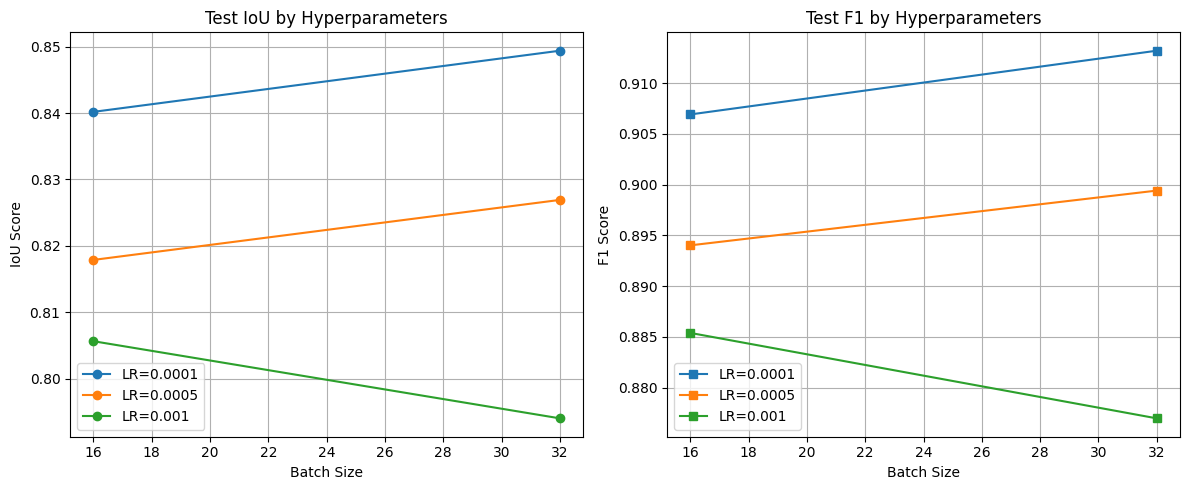


 Best combination: LR=0.0001, Batch Size=32.0
   IoU=0.8494, F1=0.9132


In [24]:
config = Config()

trainer = Trainer(config)

results_df = trainer.tune_hyperparameters(
    lr_values=[1e-4, 5e-4, 1e-3],
    batch_sizes=[16, 32],
    epochs=3
)

In [30]:
config = Config()
config.learning_rate = 0.0001
config.batch_size = 32
config.epochs = 15

final_trainer = Trainer(config)
final_trainer.run()

Epoch 1 / 15, Train Loss: 0.4661, Val Loss: 0.4133, Val IoU: 0.7781, Val F1-score: 0.8691


Epoch 2 / 15, Train Loss: 0.3322, Val Loss: 0.3016, Val IoU: 0.8405, Val F1-score: 0.9084


Epoch 3 / 15, Train Loss: 0.2865, Val Loss: 0.2802, Val IoU: 0.8502, Val F1-score: 0.9141


Epoch 4 / 15, Train Loss: 0.2574, Val Loss: 0.2640, Val IoU: 0.8571, Val F1-score: 0.9187


Epoch 5 / 15, Train Loss: 0.2311, Val Loss: 0.2621, Val IoU: 0.8566, Val F1-score: 0.9183


...

Epoch 14 / 15, Train Loss: 0.1115, Val Loss: 0.2206, Val IoU: 0.8794, Val F1-score: 0.9322


Epoch 15 / 15, Train Loss: 0.1124, Val Loss: 0.3052, Val IoU: 0.8547, Val F1-score: 0.9165
Testing...


Testing: 100%|██████████| 115/115 [00:58<00:00,  1.96it/s]

Test Loss: 0.2961, Test IoU: 0.8568, Test F1-score: 0.9169


(0.296104705852011,
 np.float64(0.8568490295306519),
 np.float64(0.9168571908750116))

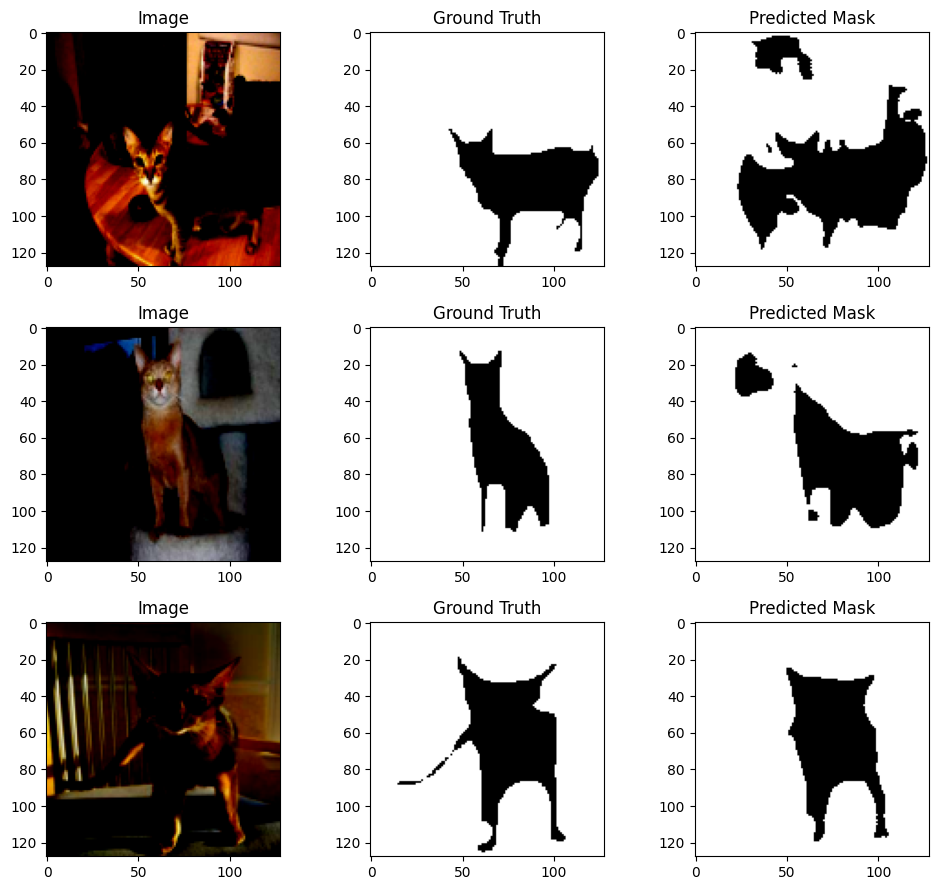

In [31]:
final_trainer.inference_and_plot_samples(n_samples=3)

In [32]:
class UNetWithDropout(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, dropout_rate=0.3):
        super(UNetWithDropout, self).__init__()

        self.enc1 = self._double_conv(in_channels, 64, dropout_rate)
        self.enc2 = self._double_conv(64, 128, dropout_rate)
        self.enc3 = self._double_conv(128, 256, dropout_rate)
        self.enc4 = self._double_conv(256, 512, dropout_rate)

        self.bottleneck = self._double_conv(512, 1024, dropout_rate)

        self.upconv4 = self._up_conv(1024, 512)
        self.dec4 = self._double_conv(1024, 512, dropout_rate)

        self.upconv3 = self._up_conv(512, 256)
        self.dec3 = self._double_conv(512, 256, dropout_rate)

        self.upconv2 = self._up_conv(256, 128)
        self.dec2 = self._double_conv(256, 128, dropout_rate)

        self.upconv1 = self._up_conv(128, 64)
        self.dec1 = self._double_conv(128, 64, dropout_rate)

        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)
        self.pool = nn.MaxPool2d(2)

    def _double_conv(self, in_channels, out_channels, dropout_rate):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_rate),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def _up_conv(self, in_channels, out_channels):
        return nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)

    def forward(self, x):
        enc1 = self.enc1(x)
        enc1_pooled = self.pool(enc1)

        enc2 = self.enc2(enc1_pooled)
        enc2_pooled = self.pool(enc2)

        enc3 = self.enc3(enc2_pooled)
        enc3_pooled = self.pool(enc3)

        enc4 = self.enc4(enc3_pooled)
        enc4_pooled = self.pool(enc4)

        bottleneck = self.bottleneck(enc4_pooled)

        up4 = self.upconv4(bottleneck)
        up4 = torch.cat([up4, enc4], dim=1)
        dec4 = self.dec4(up4)

        up3 = self.upconv3(dec4)
        up3 = torch.cat([up3, enc3], dim=1)
        dec3 = self.dec3(up3)

        up2 = self.upconv2(dec3)
        up2 = torch.cat([up2, enc2], dim=1)
        dec2 = self.dec2(up2)

        up1 = self.upconv1(dec2)
        up1 = torch.cat([up1, enc1], dim=1)
        dec1 = self.dec1(up1)

        output = self.final_conv(dec1)
        return output

In [35]:
config_dropout = Config()
config_dropout.learning_rate = 0.0001
config_dropout.batch_size = 32
config_dropout.epochs = 15

model = UNetWithDropout(dropout_rate=0.3).to(config_dropout.device)

trainer_dropout = Trainer(config_dropout, model=model)
test_loss_dropout, test_iou_dropout, test_f1_dropout = trainer_dropout.run()

print(f"\n UNet with Dropout - Test Results:")
print(f"   Loss: {test_loss_dropout:.4f}")
print(f"   IoU: {test_iou_dropout:.4f}")
print(f"   F1: {test_f1_dropout:.4f}")

Epoch 1 / 15, Train Loss: 0.5699, Val Loss: 0.4740, Val IoU: 0.7412, Val F1-score: 0.8450


Epoch 2 / 15, Train Loss: 0.4558, Val Loss: 0.4160, Val IoU: 0.7575, Val F1-score: 0.8558


Epoch 3 / 15, Train Loss: 0.4076, Val Loss: 0.4004, Val IoU: 0.7672, Val F1-score: 0.8614


Epoch 4 / 15, Train Loss: 0.3808, Val Loss: 0.3472, Val IoU: 0.8029, Val F1-score: 0.8844


Epoch 5 / 15, Train Loss: 0.3514, Val Loss: 0.3251, Val IoU: 0.8102, Val F1-score: 0.8901


...

Epoch 13 / 15, Train Loss: 0.2354, Val Loss: 0.2392, Val IoU: 0.8598, Val F1-score: 0.9205


Epoch 14 / 15, Train Loss: 0.2271, Val Loss: 0.2214, Val IoU: 0.8714, Val F1-score: 0.9275


Epoch 15 / 15, Train Loss: 0.2194, Val Loss: 0.2314, Val IoU: 0.8645, Val F1-score: 0.9232
Testing...


Testing: 100%|██████████| 115/115 [00:57<00:00,  1.99it/s]

Test Loss: 0.2262, Test IoU: 0.8656, Test F1-score: 0.9232

 UNet with Dropout - Test Results:
   Loss: 0.2262
   IoU: 0.8656
   F1: 0.9232


In [36]:
baseline_history = {
    'train_losses': final_trainer.train_losses,
    'val_losses': final_trainer.val_losses,
    'val_ious': final_trainer.val_ious,
    'val_f1s': final_trainer.val_f1s,
    'test_loss': 0.2961,
    'test_iou': 0.8568,
    'test_f1': 0.9169
}

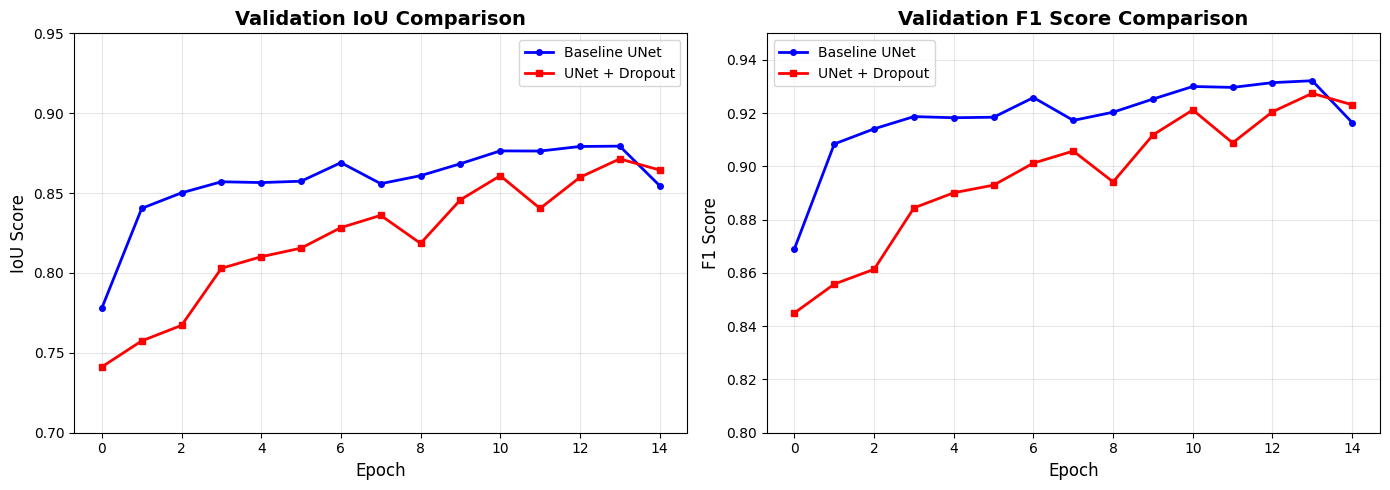

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(final_trainer.val_ious, label='Baseline UNet', marker='o', linewidth=2, markersize=4, color='blue')
axes[0].plot(trainer_dropout.val_ious, label='UNet + Dropout', marker='s', linewidth=2, markersize=4, color='red')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('IoU Score', fontsize=12)
axes[0].set_title('Validation IoU Comparison', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.7, 0.95)

axes[1].plot(final_trainer.val_f1s, label='Baseline UNet', marker='o', linewidth=2, markersize=4, color='blue')
axes[1].plot(trainer_dropout.val_f1s, label='UNet + Dropout', marker='s', linewidth=2, markersize=4, color='red')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('F1 Score', fontsize=12)
axes[1].set_title('Validation F1 Score Comparison', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.8, 0.95)

plt.tight_layout()
plt.show()

Unet с dropout показад себя немного лучше за счет добавления модификации для борьбы с переобучением